# Day 4 – t-SNE and Anomaly Detection
## Learning Objectives
At the end of this notebook, we will learn how to:
- Use t-SNE for visualization of high-dimensional data in 2D.
- Differentiate between PCA and t-SNE.
- Define the anomaly detection and explain why it is generally unsupervised.
- Use the Isolation Forest  for identifying anomalies.
- Interpret the contamination parameter.
- Examine identified anomalies and reason out why they were marked as such.

### Dataset
In this notebook, we will continue to use the same Breast Cancer  dataset from previous days
The dataset consists of numeric features describing cell nuclei with the diagnosis being the target variable.

## Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA


## Load the Dataset

In [4]:
df=pd.read_csv("breast-cancer.csv")
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


## Inspect Dataset

In [5]:
df.shape

(569, 32)

The dataset contains patient observations and numerical measurements related to cell nuclei.
The diagnosis column represents the diagnosis label and should not be used as an input feature for unsupervised learning.

In [7]:
columns_drop=[col for col in ["id","Unnamed:32"] if col in df.columns]
df=df.drop(columns=columns_drop)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Data Cleaning
the id column is only identifier and does not provide useful information for modeling.
the Unnamed:32 column is an empty column created during csv export,therefor both column are removed.

## Seperate Features and Diagnosis


In [9]:
x=df.drop("diagnosis",axis=1)
y=df["diagnosis"]
print(" Features shape is:",x.shape)
print("Target shape is:",y.shape)

 Features shape is: (569, 30)
Target shape is: (569,)


### The diagnosis column is seperated from the feature matrix
- x contains the numerical measurements.
- y contains the diagnosis labels.
the diagnosis labels will not be used by the unsupervised they will only help us understand and visualize the resulting structure.

## Scale the Features

In [11]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

There are differences between numerical values among features so standardization is required,it converts features in such a way that they will be approximately:
- Mean=0
- Standard Deviation=1
This is to avoid domination by features with large numerical values.

## Perform t-SNE
Reduce the high dimensional dataset into two dimensions by applying t-SNE,generate a 2D scatter plot based on the cluster labels generated using k-means.
The objective is the to check whether the clusters identified earlier have formed local structures.

In [12]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
cluster_labels=kmeans.fit_predict(x_scaled)
print(pd.Series(cluster_labels).value_counts().sort_index())

0    110
1    359
2    100
Name: count, dtype: int64


c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


The cluster labels are generated again using the same number of clusters used in the previous  clustering analysis
These labels are not the actual diganosis labels,they represent the group discoverd by K-Means in an unsupervised way.


## Apply t-SNE

In [17]:
tsne=TSNE(n_components=2,perplexity=30,random_state=42)
x_tsne=tsne.fit_transform(x_scaled)
x_tsne.shape

(569, 2)

t-SNE transforms the high-dimensional feature space into a two dimensional space,contracy to PCA ,t-SNE concentrates mostly on maintaining local neighborhoods,Thus it can be used for visual inspection of the presence of distinct local clusters among the observations.

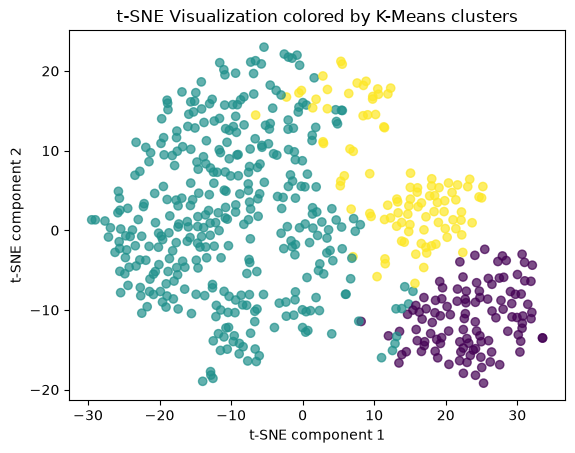

In [18]:
plt.scatter(x_tsne[:,0],x_tsne[:,1],c=cluster_labels,alpha=0.7)
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.title("t-SNE Visualization colored by K-Means clusters")
plt.show()

### Plot Analysis
In the t-SNE plot, we can see the local structure of our data according to their high dimensional feature correlation.
Colors denote the K-Means cluster assignments from the clustering analysis performed previously.
most points of the same color group together, then this implies that the t-SNE plot is exhibiting the local structure as per the discovered clusters.

## PCA vs t-SNE
In the previous day, the PCA technique was employed to reduce the high-dimensional data set to 2D space.
Now we will compare the PCA and t-SNE representations of the data.
### PCA
PCA preserves the global structure and computes linear components known as principal components.
### t-SNE
t-SNE preserves the local neighborhoods and is primarily aimed at visualization.
Thus, the PCA and t-SNE can result in different visual structures even when applied to the same data set.
| Aspect | PCA | t-SNE |
|---|---|---|
| Main goal | Dimensionality reduction and visualization | Visualization |
| Preserves | Global structure and variance | Local neighborhoods |
| Axes | Interpretable principal components | Not directly interpretable |
| Speed | Faster | Slower |
| Use in modeling | Can be used as preprocessing | Mainly for visualization |

PCA is useful when we want dimensionality reduction that can also be used in a machine-learning pipeline. t-SNE is mainly used to visually explore local structures and possible clusters.

### PCA again

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.44272026 0.18971182]


### PCA Plot

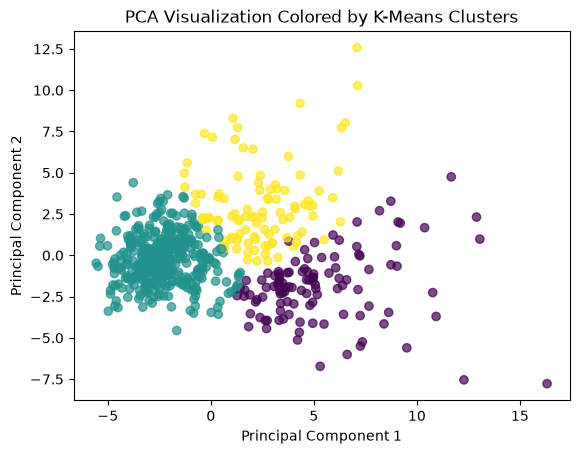

In [22]:
plt.scatter(X_pca[:, 0],X_pca[:, 1],c=cluster_labels,alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization Colored by K-Means Clusters")
plt.show()

## Plot Analysis
* Color Coding: Data points are colored using `cluster_labels` to show distinct groupings.
* Result: The output clearly displays the data separated into three different clusters across Principal Component 1 and 2.

### PCA vs. t-SNE
PCA and t-SNE offer different representations of the same high dimensional data set.
PCA tries to preserve global variance in the data, which means that distances and orientations in the plot are based on principal components.
On the other hand, t-SNE focuses on local neighborhoods and is capable of highlighting clusters of similar observations.
In our case, t-SNE offers a good visualization of local clusters, whereas PCA shows global data representation.
Thus,
- PCA is useful for reducing the number of dimensions and can also be used in a preprocessing step before building models.
- t-SNE is mostly useful for exploration and visualization of high dimensional data.
PCA has meaningful axes, whereas t-SNE axes are not interpretable.

## DBSCAN and Anomaly Detection
DBSCAN can also be related to anomaly detection. In DBSCAN, points that are
labeled as noise can be considered potential anomalies because they do not
belong to and dense cluster.
Isolation Forest approaches anomaly detection differently by isolating unusual
points through random partitions.

## Isolation Forest
Isolation Forest is an unsupervised learning method for anomaly detection.
Its basic assumption is that anomalies are simpler to isolate from others.
The algorithm performs random partitions of the data. The points that need fewer partitions to be isolated are more likely to be anomalies.
Contamination is a fraction of the dataset which is supposed to contain anomalies.

In [23]:
iso = IsolationForest(contamination=0.05,random_state=42)
anomaly_labels = iso.fit_predict(x_scaled)
print("Unique predictions:", np.unique(anomaly_labels))

Unique predictions: [-1  1]


### Results of Isolation Forest
Isolation Forest gives output as:
- `1` indicates normal value
- `-1` indicates abnormal value
The parameter `contamination` was set at `contamination=0.05`, which implies 5% observations to be anomalous.

## Count Anomalies

In [24]:
n_anomalies = (anomaly_labels == -1).sum()
n_normal = (anomaly_labels == 1).sum()
print("Total observations:", len(anomaly_labels))
print("Normal observations:", n_normal)
print("Anomalies:", n_anomalies)
print("Anomaly percentage:", round(n_anomalies / len(anomaly_labels) * 100, 2), "%")

Total observations: 569
Normal observations: 540
Anomalies: 29
Anomaly percentage: 5.1 %


### Interpretation
Isolation Forest considered the observations with the predicted value of -1 as anomalies.
Since the value of contamination is 0.05, 5% of the observations should be flagged.
The actual number will depend on the dataset and the process of thresholding in Isolation Forest.

## Inspection of Two Anomalies
Two observations will be inspected, which were identified as anomalies using the Isolation Forest method.
The is not to show that these observations are erroneous or incorrect.
The idea is to look at the value of their features and explain what might have made them different from the other observations.

In [25]:
anomaly_indices = np.where(anomaly_labels == -1)[0]
print("First anomaly indices:")
print(anomaly_indices[:10])

First anomaly indices:
[  0   3   9  12  42  68  71  78  82 108]


## Inspect two Anomalies

In [27]:
two_anomalies = x.iloc[anomaly_indices[:2]]
two_anomalies

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730


## Compare them with Dataset Statistics

In [31]:
comparison = pd.DataFrame({"Anomaly 1": x.iloc[anomaly_indices[0]],"Anomaly 2": x.iloc[anomaly_indices[1]],"Dataset Mean": x.mean()})
comparison.head(10)

,Anomaly 1,Anomaly 2,Dataset Mean
radius_mean,17.99000,11.42000,14.127292
texture_mean,10.38000,20.38000,19.289649
perimeter_mean,122.80000,77.58000,91.969033
area_mean,1001.00000,386.10000,654.889104
smoothness_mean,0.11840,0.14250,0.096360
compactness_mean,0.27760,0.28390,0.104341
concavity_mean,0.30010,0.24140,0.088799
concave points_mean,0.14710,0.10520,0.048919
symmetry_mean,0.24190,0.25970,0.181162
fractal_dimension_mean,0.07871,0.09744,0.062798


### Analyzing the Anomalous Observations
The two above observations are marked as anomalous by Isolation Forest.
To see why this is so, we have to look at the feature values and compare them with the dataset characteristics.
Those features that have significantly different values from the common values can be one of the reasons for the observation to be isolated.
Nevertheless, Isolation Forest uses all the features together and not just one of them.

### Interpretation of Two Anomalies
### Anomaly 1
This observation has noticeably higher values for features such as
radius_mean, perimeter_mean, and area_mean compared with the dataset mean.
It also has relatively high compactness and concavity values.
This combination of measurements may make the observation easier to isolate
from the majority of observations.

### Anomaly 2
This observation has relatively low values for radius_mean, perimeter_mean,
and area_mean compared with the dataset mean, while some other features are
higher than average.
The unusual combination of these measurements may have caused Isolation Forest
to isolate this observation.
These points are potential anomalies, not necessarily incorrect observations.

## Visualization of Anomalies

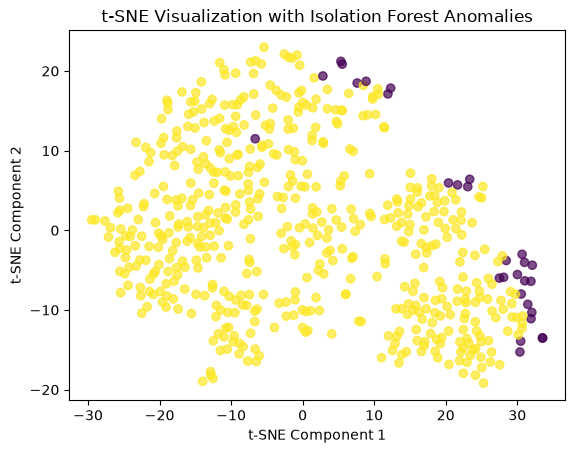

In [32]:
plt.scatter(x_tsne[:, 0],x_tsne[:, 1],c=anomaly_labels,alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization with Isolation Forest Anomalies")
plt.show()

### Plot Analysis
The output clearly separates the normal data points (yellow) from the detected anomalies (purple).

# Hands-On-Lab
All required tasks for Day 4 were completed:
-  **Step 1:** Apply t-SNE to reduce a high-dimensional dataset to 2D and plot it, coloring by cluster from Day 1
- t-SNE technique was used to lower the dimensionality of the data set to 2D and plot the data using K-Means clustering labels.
-  **Step 2:** Compare the t-SNE plot to the PCA plot from Day 3 and note what each reveals
- Compared the t-SNE plot with PCA and described the differences between the local structure and the global structure.
-  **Step 3:** Run Isolation Forest on the dataset and report how many points were flagged as anomalies.
- Used Isolation Forest algorithm with `contamination=0.05` and detected 29 observations as outliers.
-  **Step 4:**  Inspect two flagged points and hypothesize why they were flagged, documented in Markdown.
- Evaluated two outlier observations and explained the possible causes for detecting them as outliers.
All tasks were completed and explained in the steps above.
